In [1]:
import importlib

In [2]:
import sys
sys.path.append("../src/meta-estimators")

In [3]:
import pandas as pd
import mygene

mg = mygene.MyGeneInfo()

def ensg_to_symbol(ensg_ids):
    # Remove version suffixes like ENSG00000141510.18
    clean_ids = pd.Series(ensg_ids).astype(str).str.replace(r"\.\d+$", "", regex=True)

    res = mg.querymany(
        clean_ids.tolist(),
        scopes="ensembl.gene",
        fields="symbol",
        species="human",
        as_dataframe=True,
    )

    mapping = res["symbol"].to_dict()
    return clean_ids.map(mapping).values

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Asthayadav09/airway-RNA-Seq-Dataset/main/airway_DESeq2_results.csv", index_col=0)
df["symbol"] = ensg_to_symbol(df.index)

In [5]:
df = df.dropna().set_index("symbol")
df = df.reset_index().drop_duplicates(subset=["symbol"]).set_index("symbol")

In [6]:
from enrichr import GeneOntologyLibraries
go_terms = GeneOntologyLibraries().pull_assignment_matrix("GO_Biological_Process_2025")

In [8]:
import ipf
import importlib
importlib.reload(ipf)
from ipf import ReweightingPreparer, IterativeProportionalFitting

deseq_results, go_terms, row_marginals, column_marginals = ReweightingPreparer.clean(go_terms, df)
balanced_matrix = IterativeProportionalFitting().sinkhorn_binary_support(
    row_marginals=row_marginals, 
    column_marginals=column_marginals,
    A=go_terms, 
    prior="degree_corrected"
)

100%|██████████| 10000/10000 [00:03<00:00, 2814.20it/s]


<Axes: xlabel='metaLFC', ylabel='log10padj'>

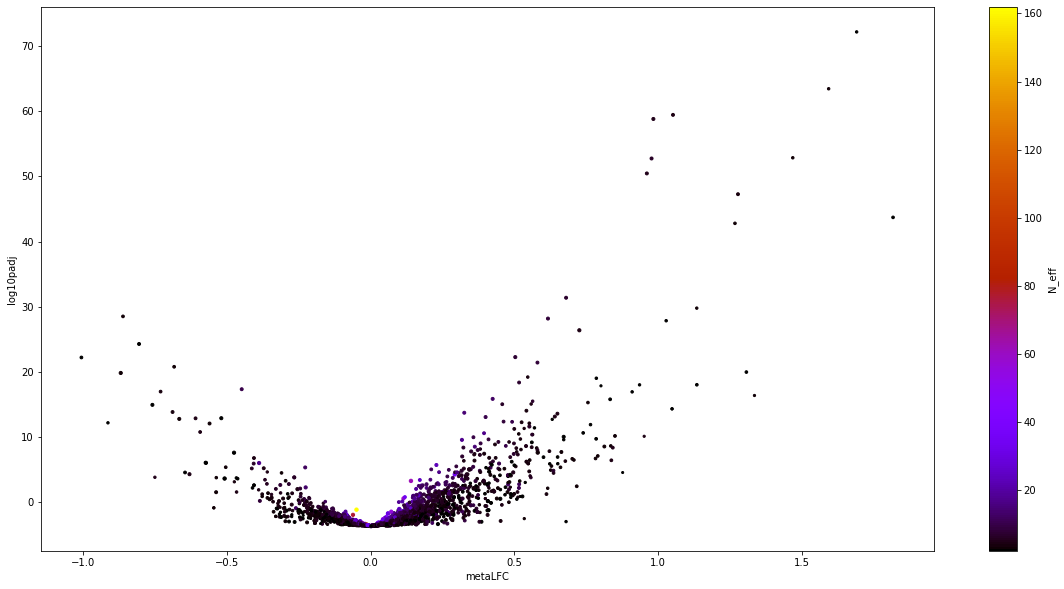

In [10]:
import numpy as np
from meta import GeneOntologyDifferentialResults

gene_ontology_results = GeneOntologyDifferentialResults.meta_estimates(deseq_results, balanced_matrix)

gene_ontology_results["log_weight"] = np.log1p(gene_ontology_results["weight"])

gene_ontology_results.query("top1_contribution < 0.9 and N_eff > 2") \
    .plot.scatter(x="metaLFC", y="log10padj", c="N_eff", s="log_weight", figsize=(20, 10), cmap="gnuplot")

<Axes: xlabel='N_eff', ylabel='metaLFC'>

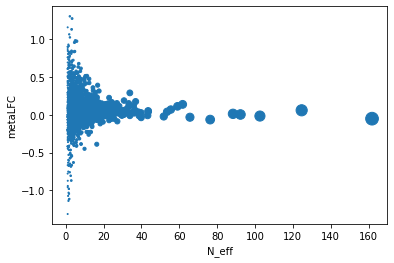

In [11]:
gene_ontology_results.eval("ratio = N_eff / n_terms").query("n_terms > 10").plot.scatter(x="N_eff", y="metaLFC", s="N_eff")

In [ ]:
import seaborn as sns
sns.clustermap(balanced_matrix)

/Users/jameshaberberger/GitHub/meta-estimators/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


In [72]:
import matplotlib.pyplot as plt

gene_ontology_results.query("padj < 0.05 and N_eff > 2").sort_values(by="metaLFC")

,n_terms,metaLFC,metaSE,lower_ci,upper_ci,weight,pval,padj,log10p,log10padj,top1_contribution,top5_contribution,N_eff,log_weight
Acidic Amino Acid Transport (GO:0015800),9,-0.972820,0.174087,-1.314031,-0.631609,309.447840,2.295395e-08,1.224134e-04,7.639143,3.912171,0.456805,0.878866,3.800380,6.738016
Regulation of Epithelial to Mesenchymal Transition (GO:0010717),74,-0.870530,0.085251,-1.037622,-0.703439,19721.609197,1.763285e-24,9.403597e-21,23.753678,20.026706,0.575847,0.736513,2.926338,10.889521
Diol Metabolic Process (GO:0034311),8,-0.859141,0.071886,-1.000037,-0.718245,1560.286231,6.376788e-33,3.400741e-29,32.195398,28.468426,0.570590,0.977807,2.718399,8.353265
Regulation of Neuron Migration (GO:2001222),25,-0.804358,0.072338,-0.946140,-0.662576,6237.710315,1.008863e-28,5.380267e-25,27.996168,24.269196,0.520963,0.931091,2.592633,9.738529
Response to UV (GO:0009411),95,-0.758070,0.084301,-0.923299,-0.592840,7941.286725,2.418106e-19,1.289576e-15,18.616525,14.889553,0.669356,0.943391,2.071637,9.979957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Detection of Mechanical Stimulus Involved in Sensory Perception of Sound (GO:0050910),8,1.391814,0.140294,1.116838,1.666789,142.283991,3.382898e-23,1.804100e-19,22.470711,18.743740,0.539906,0.935266,2.933439,5.964829
Cellular Response to Cadmium Ion (GO:0071276),9,1.533315,0.094339,1.348412,1.718219,454.375466,2.116492e-59,1.128725e-55,58.674383,54.947412,0.555115,0.944300,2.826413,7.121122
Response to Cadmium Ion (GO:0046686),8,1.645995,0.093413,1.462906,1.829084,381.690671,1.709359e-69,9.116012e-66,68.767167,65.040195,0.551393,0.973485,2.828055,6.947227
Copper Ion Transport (GO:0006825),9,1.689000,0.091135,1.510375,1.867626,364.585955,1.121740e-76,5.982240e-73,75.950108,72.223136,0.588529,0.991564,2.101119,6.901501


/Users/jameshaberberger/GitHub/meta-estimators/notebook/../src/meta-estimators/plotting.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


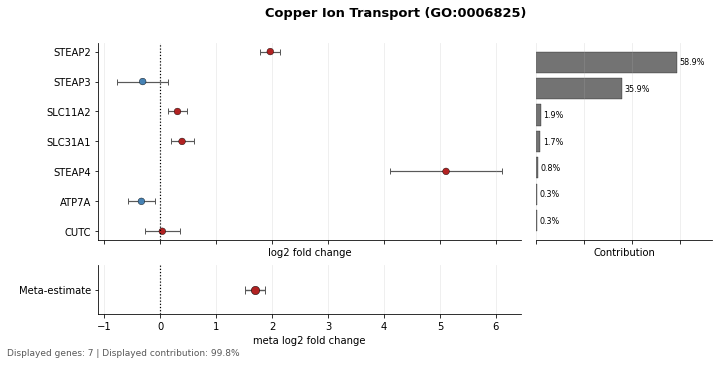

In [73]:
from plotting import ForestPlotter

term = "Copper Ion Transport (GO:0006825)"
output = ForestPlotter(deseq_results, balanced_matrix, gene_ontology_results).plot_term(term, cutoff=0.999)